In [2]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# Data handling
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Data display
from IPython.display import display

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data splitting and model tuning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# Model evaluation
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Bootstrap validation
from sklearn.utils import resample
from sklearn.base import clone

# Partial dependence plots
from sklearn.inspection import (
    PartialDependenceDisplay,
    partial_dependence
)

# Saving the final model
import joblib

# Ignore unnecessary warning messages
warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [3]:
# ============================================================
# LOAD THE ORIGINAL 175-OBSERVATION DATASET
# ============================================================

import os
import numpy as np
import pandas as pd

file_path = (
    r"D:\MSC THESIS AAVAS\AFTER MID DEFENSE"
    r"\Final data without IRI\Data_without_IRI.xlsx"
)

df_original = pd.read_excel(
    file_path,
    engine="openpyxl"
)

print("Original observations:", len(df_original))

display(df_original.head())

Original observations: 175


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,57.0,1.27,inf,5.5,0.9,Gravel,0.9,Gravel
1,2,33.0,2.92,46.0,5.5,0.9,Gravel,0.9,Gravel
2,3,43.0,7.97,inf,5.5,0.9,Gravel,0.9,Gravel
3,4,48.0,2.07,inf,5.5,0.9,Gravel,0.9,Gravel
4,5,36.0,1.21,16.0,5.5,0.9,Gravel,0.9,Gravel


In [4]:
# ============================================================
# CLEAN THE ORIGINAL DATASET
# ============================================================

df_clean = df_original.copy()

# Remove spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Clean shoulder-type categories
for column in [
    "Left Shoulder Type",
    "Right Shoulder Type"
]:
    df_clean[column] = (
        df_clean[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.capitalize()
    )

# Identify tangent sections before replacing infinity
df_clean["Is_Tangent"] = np.isinf(
    df_clean["Radius of Curve"]
).astype(int)

# Assign tangent sections a radius of 1500 m
df_clean["Radius of Curve"] = (
    df_clean["Radius of Curve"]
    .replace(
        [np.inf, -np.inf],
        1500
    )
)

# Create average shoulder width
df_clean["Average Shoulder Width"] = (
    df_clean["Left Shoulder Width"] +
    df_clean["Right Shoulder Width"]
) / 2

print("Dataset cleaned successfully.")
print("Observations:", len(df_clean))
print("Tangent sections:", df_clean["Is_Tangent"].sum())

Dataset cleaned successfully.
Observations: 175
Tangent sections: 49


In [5]:
# ============================================================
# INFLUENTIAL SITE NUMBERS FROM THE DIAGNOSTIC ANALYSIS
# ============================================================

influential_sn = [
    6,
    13,
    29,
    71,
    75,
    88,
    94,
    98,
    133,
    135,
    161
]

print("Number of influential sites:", len(influential_sn))
print("Site numbers:", influential_sn)

Number of influential sites: 11
Site numbers: [6, 13, 29, 71, 75, 88, 94, 98, 133, 135, 161]


In [6]:
# ============================================================
# VERIFY THE SITE NUMBERS
# ============================================================

available_sn = set(
    df_clean["SN"].tolist()
)

missing_sn = [
    sn
    for sn in influential_sn
    if sn not in available_sn
]

if missing_sn:
    raise ValueError(
        f"These SN values were not found: {missing_sn}"
    )

print("All influential SN values were found.")

All influential SN values were found.


In [7]:
# ============================================================
# EXTRACT THE OBSERVATIONS PROPOSED FOR REMOVAL
# ============================================================

removed_observations = (
    df_clean[
        df_clean["SN"].isin(influential_sn)
    ]
    .copy()
    .sort_values("SN")
)

print(
    "Number of observations selected for exclusion:",
    len(removed_observations)
)

display(
    removed_observations[
        [
            "SN",
            "V85 Speed",
            "Gradient",
            "Radius of Curve",
            "Carriageway Width",
            "Left Shoulder Width",
            "Right Shoulder Width",
            "Average Shoulder Width",
            "Is_Tangent"
        ]
    ]
)

Number of observations selected for exclusion: 11


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width,Is_Tangent
5,6,74.00,3.160,1500.0,5.500,0.90,0.9,0.900,1
12,13,39.10,0.500,1500.0,7.500,0.59,0.7,0.645,1
28,29,61.00,0.287,60.0,4.944,0.00,0.6,0.300,0
70,71,38.40,5.050,1500.0,7.000,1.00,1.0,1.000,1
74,75,67.25,0.700,1500.0,7.000,1.00,1.0,1.000,1
87,88,24.00,1.785,15.0,6.000,0.00,0.5,0.250,0
93,94,65.65,7.920,200.0,6.000,0.00,0.0,0.000,0
97,98,72.00,6.475,1500.0,7.000,0.75,0.0,0.375,1
132,133,61.30,7.690,100.0,7.000,0.50,0.0,0.250,0
134,135,28.90,1.380,1500.0,7.000,0.50,0.0,0.250,1


In [8]:
# ============================================================
# CREATE REDUCED DATASET
# ============================================================

df_reduced = (
    df_clean[
        ~df_clean["SN"].isin(influential_sn)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Original cleaned observations:", len(df_clean))
print("Removed observations:", len(removed_observations))
print("Reduced observations:", len(df_reduced))

Original cleaned observations: 175
Removed observations: 11
Reduced observations: 164


In [9]:
# ============================================================
# VALIDATE REDUCED DATASET
# ============================================================

assert len(df_reduced) == 164, (
    "The reduced dataset should contain 164 observations."
)

assert not df_reduced["SN"].isin(
    influential_sn
).any(), (
    "Some influential SN values remain."
)

required_numeric_columns = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width"
]

assert (
    df_reduced[required_numeric_columns]
    .isna()
    .sum()
    .sum()
    == 0
), "Missing values remain."

assert not np.isinf(
    df_reduced[required_numeric_columns]
).any().any(), (
    "Infinite values remain."
)

assert df_reduced["SN"].duplicated().sum() == 0, (
    "Duplicate SN values are present."
)

print("Reduced dataset passed all validation checks.")

Reduced dataset passed all validation checks.


In [10]:
# ============================================================
# SAVE REDUCED DATASET AND REMOVED OBSERVATIONS
# ============================================================

output_folder = os.path.dirname(
    file_path
)

reduced_file_path = os.path.join(
    output_folder,
    "Data_without_IRI_reduced_164.xlsx"
)

removed_file_path = os.path.join(
    output_folder,
    "Removed_influential_observations.xlsx"
)

df_reduced.to_excel(
    reduced_file_path,
    index=False
)

removed_observations.to_excel(
    removed_file_path,
    index=False
)

print("Reduced dataset saved to:")
print(reduced_file_path)

print("\nRemoved observations saved to:")
print(removed_file_path)

Reduced dataset saved to:
D:\MSC THESIS AAVAS\AFTER MID DEFENSE\Final data without IRI\Data_without_IRI_reduced_164.xlsx

Removed observations saved to:
D:\MSC THESIS AAVAS\AFTER MID DEFENSE\Final data without IRI\Removed_influential_observations.xlsx


In [11]:
# ============================================================
# COMPARE ORIGINAL AND REDUCED DATASETS
# ============================================================

comparison_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width"
]

comparison_table = pd.DataFrame({
    "Original Mean": (
        df_clean[comparison_variables].mean()
    ),

    "Reduced Mean": (
        df_reduced[comparison_variables].mean()
    ),

    "Original SD": (
        df_clean[comparison_variables].std()
    ),

    "Reduced SD": (
        df_reduced[comparison_variables].std()
    ),

    "Original Minimum": (
        df_clean[comparison_variables].min()
    ),

    "Reduced Minimum": (
        df_reduced[comparison_variables].min()
    ),

    "Original Maximum": (
        df_clean[comparison_variables].max()
    ),

    "Reduced Maximum": (
        df_reduced[comparison_variables].max()
    )
})

display(
    comparison_table.round(3)
)

,Original Mean,Reduced Mean,Original SD,Reduced SD,Original Minimum,Reduced Minimum,Original Maximum,Reduced Maximum
V85 Speed,45.171,44.776,10.327,9.444,24.00,25.00,74.000,67.00
Gradient,4.144,4.141,2.559,2.482,0.07,0.07,11.085,10.00
Radius of Curve,478.183,452.878,642.352,629.633,15.00,15.00,1500.000,1500.00
Carriageway Width,6.295,6.287,0.901,0.907,4.70,4.70,8.000,8.00
Average Shoulder Width,0.610,0.615,0.348,0.347,0.00,0.00,1.030,1.03


,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width
V85 Speed,1.000,-0.117,0.615,0.089,-0.202
Gradient,-0.117,1.000,-0.168,-0.150,-0.048
Radius of Curve,0.615,-0.168,1.000,-0.014,-0.108
Carriageway Width,0.089,-0.150,-0.014,1.000,-0.047
Average Shoulder Width,-0.202,-0.048,-0.108,-0.047,1.000


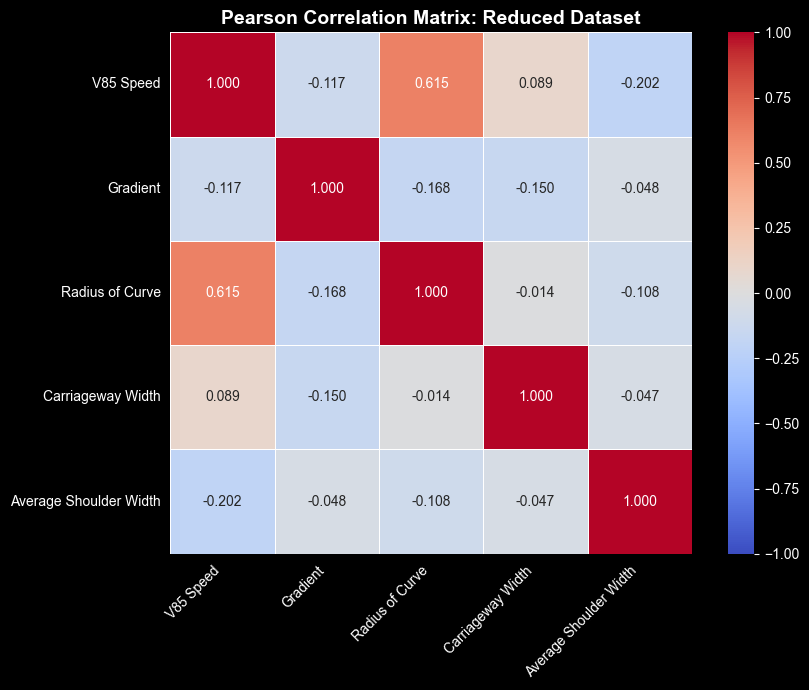

In [12]:
# ============================================================
# PEARSON CORRELATION FOR REDUCED DATASET
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

correlation_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width"
]

reduced_pearson = (
    df_reduced[correlation_variables]
    .corr(method="pearson")
)

display(
    reduced_pearson.round(3)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    reduced_pearson,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.7
)

plt.title(
    "Pearson Correlation Matrix: Reduced Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# VIF FOR REDUCED DATASET
# ============================================================

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

selected_predictors = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width"
]

X_vif_reduced = (
    df_reduced[selected_predictors]
    .astype(float)
)

X_vif_reduced_constant = sm.add_constant(
    X_vif_reduced,
    has_constant="add"
)

vif_reduced = pd.DataFrame({
    "Variable": X_vif_reduced_constant.columns,

    "VIF": [
        variance_inflation_factor(
            X_vif_reduced_constant.values,
            index
        )
        for index in range(
            X_vif_reduced_constant.shape[1]
        )
    ]
})

vif_reduced["Tolerance"] = (
    1 / vif_reduced["VIF"]
)

vif_reduced = (
    vif_reduced[
        vif_reduced["Variable"] != "const"
    ]
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    vif_reduced.round(3)
)

,Variable,VIF,Tolerance
0,Gradient,1.060,0.943
1,Radius of Curve,1.046,0.956
2,Carriageway Width,1.028,0.972
3,Average Shoulder Width,1.020,0.980


In [14]:
# ============================================================
# DEFINE MODELING VARIABLES FOR REDUCED DATASET
# ============================================================

X_reduced = df_reduced[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Average Shoulder Width"
    ]
].copy()

y_reduced = (
    df_reduced["V85 Speed"]
    .copy()
)

print("X shape:", X_reduced.shape)
print("y shape:", y_reduced.shape)

X shape: (164, 4)
y shape: (164,)


In [15]:
# ============================================================
# NEW 80:20 TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train_reduced, X_test_reduced, \
y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.20,
    random_state=42
)

print(
    "Training observations:",
    len(X_train_reduced)
)

print(
    "Testing observations:",
    len(X_test_reduced)
)

Training observations: 131
Testing observations: 33


In [16]:
# ============================================================
# CHECK REDUCED TRAINING AND TESTING DATA
# ============================================================

print("X_train_reduced shape:", X_train_reduced.shape)
print("X_test_reduced shape :", X_test_reduced.shape)
print("y_train_reduced shape:", y_train_reduced.shape)
print("y_test_reduced shape :", y_test_reduced.shape)

print("\nPredictors used:")

for column in X_train_reduced.columns:
    print(column)

X_train_reduced shape: (131, 4)
X_test_reduced shape : (33, 4)
y_train_reduced shape: (131,)
y_test_reduced shape : (33,)

Predictors used:
Gradient
Radius of Curve
Carriageway Width
Average Shoulder Width


In [17]:
# ============================================================
# VALIDATE REDUCED MODELING DATA
# ============================================================

assert X_train_reduced.isna().sum().sum() == 0
assert X_test_reduced.isna().sum().sum() == 0
assert y_train_reduced.isna().sum() == 0
assert y_test_reduced.isna().sum() == 0

assert not np.isinf(X_train_reduced).any().any()
assert not np.isinf(X_test_reduced).any().any()
assert not np.isinf(y_train_reduced).any()
assert not np.isinf(y_test_reduced).any()

print("Reduced training and testing data passed validation.")

Reduced training and testing data passed validation.


In [18]:
# ============================================================
# STANDARDIZE REDUCED DATA FOR MLR
# ============================================================

scaler_mlr_reduced = StandardScaler()

# Fit only on training predictors
X_train_reduced_scaled = scaler_mlr_reduced.fit_transform(
    X_train_reduced
)

# Apply the same transformation to the test predictors
X_test_reduced_scaled = scaler_mlr_reduced.transform(
    X_test_reduced
)

print("Reduced predictors standardized successfully.")

print(
    "Scaled training shape:",
    X_train_reduced_scaled.shape
)

print(
    "Scaled testing shape:",
    X_test_reduced_scaled.shape
)

Reduced predictors standardized successfully.
Scaled training shape: (131, 4)
Scaled testing shape: (33, 4)


In [19]:
# ============================================================
# CHECK STANDARDIZED TRAINING VARIABLES
# ============================================================

scaling_check = pd.DataFrame(
    X_train_reduced_scaled,
    columns=X_train_reduced.columns
).agg(
    ["mean", "std"]
).T

display(
    scaling_check.round(3)
)

,mean,std
Gradient,-0.0,1.004
Radius of Curve,-0.0,1.004
Carriageway Width,-0.0,1.004
Average Shoulder Width,0.0,1.004


In [20]:
# ============================================================
# TRAIN MLR ON REDUCED DATASET
# ============================================================

mlr_reduced = LinearRegression()

mlr_reduced.fit(
    X_train_reduced_scaled,
    y_train_reduced
)

print("Reduced-dataset MLR model trained successfully.")

Reduced-dataset MLR model trained successfully.


In [21]:
# ============================================================
# GENERATE MLR PREDICTIONS
# ============================================================

y_train_pred_mlr_reduced = mlr_reduced.predict(
    X_train_reduced_scaled
)

y_test_pred_mlr_reduced = mlr_reduced.predict(
    X_test_reduced_scaled
)

print(
    "Training predictions:",
    len(y_train_pred_mlr_reduced)
)

print(
    "Testing predictions:",
    len(y_test_pred_mlr_reduced)
)

Training predictions: 131
Testing predictions: 33


In [22]:
# ============================================================
# MLR TRAINING PERFORMANCE
# ============================================================

mlr_reduced_train_r2 = r2_score(
    y_train_reduced,
    y_train_pred_mlr_reduced
)

mlr_reduced_train_rmse = np.sqrt(
    mean_squared_error(
        y_train_reduced,
        y_train_pred_mlr_reduced
    )
)

mlr_reduced_train_mae = mean_absolute_error(
    y_train_reduced,
    y_train_pred_mlr_reduced
)

print("Training metrics calculated.")

Training metrics calculated.


In [23]:
# ============================================================
# MLR TESTING PERFORMANCE
# ============================================================

mlr_reduced_test_r2 = r2_score(
    y_test_reduced,
    y_test_pred_mlr_reduced
)

mlr_reduced_test_rmse = np.sqrt(
    mean_squared_error(
        y_test_reduced,
        y_test_pred_mlr_reduced
    )
)

mlr_reduced_test_mae = mean_absolute_error(
    y_test_reduced,
    y_test_pred_mlr_reduced
)

print("Testing metrics calculated.")

Testing metrics calculated.


In [24]:
# ============================================================
# MLR: TRAINING VS TESTING RESULTS
# ============================================================

mlr_reduced_train_test_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],

    "R2": [
        mlr_reduced_train_r2,
        mlr_reduced_test_r2
    ],

    "RMSE": [
        mlr_reduced_train_rmse,
        mlr_reduced_test_rmse
    ],

    "MAE": [
        mlr_reduced_train_mae,
        mlr_reduced_test_mae
    ]
})

display(
    mlr_reduced_train_test_results.round(3)
)

,Dataset,R2,RMSE,MAE
0,Training,0.413,7.536,6.039
1,Testing,0.283,6.088,4.803


In [25]:
# ============================================================
# REDUCED MLR TEST-SET RESULTS
# ============================================================

mlr_reduced_results = pd.DataFrame({
    "Metric": [
        "R2",
        "RMSE",
        "MAE"
    ],

    "Value": [
        mlr_reduced_test_r2,
        mlr_reduced_test_rmse,
        mlr_reduced_test_mae
    ]
})

display(
    mlr_reduced_results.round(3)
)

,Metric,Value
0,R2,0.283
1,RMSE,6.088
2,MAE,4.803


In [26]:
# ============================================================
# REDUCED MLR COEFFICIENT TABLE
# ============================================================

mlr_reduced_coefficients = pd.DataFrame({
    "Variable": X_train_reduced.columns,
    "Coefficient": mlr_reduced.coef_
})

intercept_row = pd.DataFrame({
    "Variable": ["Constant"],
    "Coefficient": [mlr_reduced.intercept_]
})

mlr_reduced_coefficients = pd.concat(
    [
        intercept_row,
        mlr_reduced_coefficients
    ],
    ignore_index=True
)

display(
    mlr_reduced_coefficients.round(4)
)

,Variable,Coefficient
0,Constant,45.2802
1,Gradient,-0.3084
2,Radius of Curve,6.0006
3,Carriageway Width,0.9516
4,Average Shoulder Width,-1.1895


In [27]:
# ============================================================
# RANK STANDARDIZED MLR COEFFICIENTS
# ============================================================

mlr_reduced_coefficient_ranking = pd.DataFrame({
    "Variable": X_train_reduced.columns,
    "Coefficient": mlr_reduced.coef_,
    "Absolute Coefficient": np.abs(
        mlr_reduced.coef_
    )
})

mlr_reduced_coefficient_ranking = (
    mlr_reduced_coefficient_ranking
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    mlr_reduced_coefficient_ranking.round(4)
)

,Variable,Coefficient,Absolute Coefficient
0,Radius of Curve,6.0006,6.0006
1,Average Shoulder Width,-1.1895,1.1895
2,Carriageway Width,0.9516,0.9516
3,Gradient,-0.3084,0.3084


In [28]:
# ============================================================
# PRINT STANDARDIZED MLR EQUATION
# ============================================================

mlr_equation_reduced = (
    f"V85 = {mlr_reduced.intercept_:.4f}"
)

for variable, coefficient in zip(
    X_train_reduced.columns,
    mlr_reduced.coef_
):

    sign = "+" if coefficient >= 0 else "-"

    mlr_equation_reduced += (
        f" {sign} "
        f"{abs(coefficient):.4f}"
        f"(Z_{variable})"
    )

print("Standardized MLR equation:\n")
print(mlr_equation_reduced)

Standardized MLR equation:

V85 = 45.2802 - 0.3084(Z_Gradient) + 6.0006(Z_Radius of Curve) + 0.9516(Z_Carriageway Width) - 1.1895(Z_Average Shoulder Width)


In [29]:
# ============================================================
# ACTUAL AND PREDICTED TEST VALUES
# ============================================================

mlr_reduced_prediction_table = pd.DataFrame({
    "Actual V85": y_test_reduced,
    "Predicted V85": y_test_pred_mlr_reduced
})

mlr_reduced_prediction_table["Residual"] = (
    mlr_reduced_prediction_table["Actual V85"] -
    mlr_reduced_prediction_table["Predicted V85"]
)

mlr_reduced_prediction_table["Absolute Error"] = (
    mlr_reduced_prediction_table["Residual"].abs()
)

mlr_reduced_prediction_table = (
    mlr_reduced_prediction_table
    .sort_index()
)

display(
    mlr_reduced_prediction_table.round(3)
)

,Actual V85,Predicted V85,Residual,Absolute Error
9,49.55,51.829,-2.279,2.279
12,58.20,55.917,2.283,2.283
15,48.00,42.406,5.594,5.594
16,43.00,41.171,1.829,1.829
18,45.00,39.984,5.016,5.016
19,42.00,39.858,2.142,2.142
24,39.00,38.770,0.230,0.230
29,50.30,40.231,10.069,10.069
30,44.00,39.708,4.292,4.292
31,33.00,41.022,-8.022,8.022


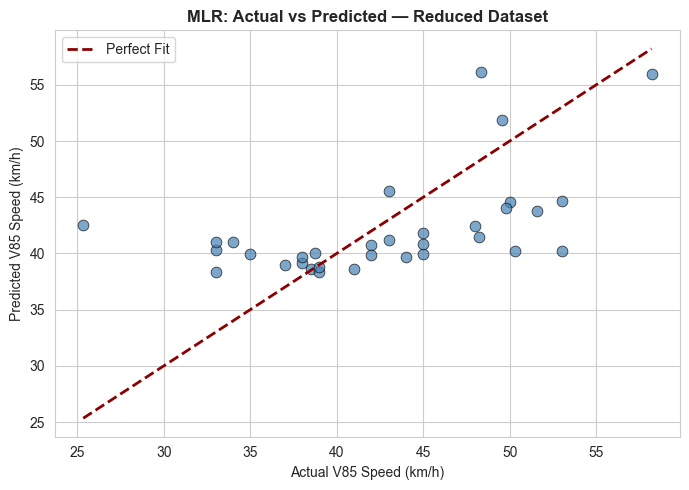

In [30]:
# ============================================================
# REDUCED MLR: ACTUAL VS PREDICTED
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_reduced,
    y=y_test_pred_mlr_reduced,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

minimum_value = min(
    y_test_reduced.min(),
    y_test_pred_mlr_reduced.min()
)

maximum_value = max(
    y_test_reduced.max(),
    y_test_pred_mlr_reduced.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed (km/h)")
plt.ylabel("Predicted V85 Speed (km/h)")

plt.title(
    "MLR: Actual vs Predicted — Reduced Dataset",
    fontsize=12,
    fontweight="bold"
)

plt.legend()
plt.tight_layout()
plt.show()

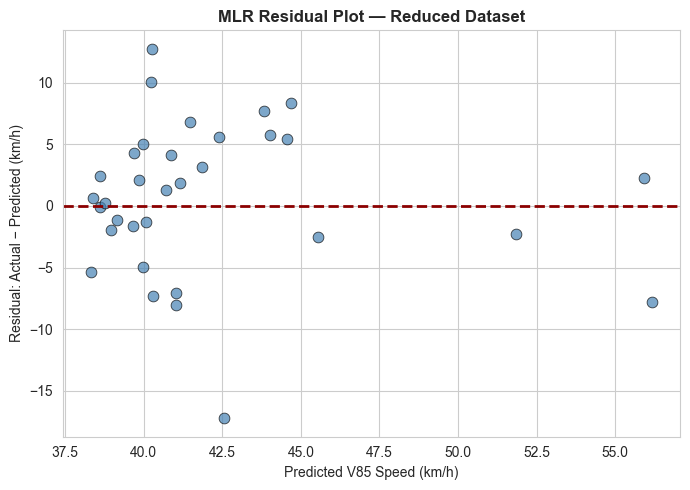

In [31]:
# ============================================================
# REDUCED MLR: RESIDUAL PLOT
# ============================================================

mlr_reduced_residuals = (
    y_test_reduced -
    y_test_pred_mlr_reduced
)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_pred_mlr_reduced,
    y=mlr_reduced_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    color="darkred",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted V85 Speed (km/h)")
plt.ylabel("Residual: Actual − Predicted (km/h)")

plt.title(
    "MLR Residual Plot — Reduced Dataset",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# STORE REDUCED MLR RESULT
# ============================================================

mlr_reduced_final = pd.DataFrame({
    "Model": [
        "MLR — Reduced Dataset"
    ],

    "Observations": [
        len(df_reduced)
    ],

    "R2": [
        mlr_reduced_test_r2
    ],

    "RMSE": [
        mlr_reduced_test_rmse
    ],

    "MAE": [
        mlr_reduced_test_mae
    ]
})

display(
    mlr_reduced_final.round(3)
)

,Model,Observations,R2,RMSE,MAE
0,MLR — Reduced Dataset,164,0.283,6.088,4.803


In [33]:
# ============================================================
# TRAIN BASE RANDOM FOREST
# Unscaled predictors are used
# ============================================================

rf_reduced = RandomForestRegressor(
    random_state=42
)

rf_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

print("Base Random Forest trained successfully.")

Base Random Forest trained successfully.


In [34]:
# ============================================================
# DISPLAY BASE RANDOM FOREST SETTINGS
# ============================================================

print(rf_reduced)

RandomForestRegressor(random_state=42)


In [35]:
# ============================================================
# BASE RANDOM FOREST PREDICTIONS
# ============================================================

y_train_pred_rf_reduced = rf_reduced.predict(
    X_train_reduced
)

y_test_pred_rf_reduced = rf_reduced.predict(
    X_test_reduced
)

print(
    "Training predictions:",
    len(y_train_pred_rf_reduced)
)

print(
    "Testing predictions:",
    len(y_test_pred_rf_reduced)
)

Training predictions: 131
Testing predictions: 33


In [36]:
# ============================================================
# BASE RF TRAINING PERFORMANCE
# ============================================================

rf_reduced_train_r2 = r2_score(
    y_train_reduced,
    y_train_pred_rf_reduced
)

rf_reduced_train_rmse = np.sqrt(
    mean_squared_error(
        y_train_reduced,
        y_train_pred_rf_reduced
    )
)

rf_reduced_train_mae = mean_absolute_error(
    y_train_reduced,
    y_train_pred_rf_reduced
)

print("Training metrics calculated.")

Training metrics calculated.


In [37]:
# ============================================================
# BASE RF TESTING PERFORMANCE
# ============================================================

rf_reduced_test_r2 = r2_score(
    y_test_reduced,
    y_test_pred_rf_reduced
)

rf_reduced_test_rmse = np.sqrt(
    mean_squared_error(
        y_test_reduced,
        y_test_pred_rf_reduced
    )
)

rf_reduced_test_mae = mean_absolute_error(
    y_test_reduced,
    y_test_pred_rf_reduced
)

print("Testing metrics calculated.")

Testing metrics calculated.


In [38]:
# ============================================================
# BASE RF: TRAINING VS TESTING RESULTS
# ============================================================

rf_reduced_train_test_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],

    "R2": [
        rf_reduced_train_r2,
        rf_reduced_test_r2
    ],

    "RMSE": [
        rf_reduced_train_rmse,
        rf_reduced_test_rmse
    ],

    "MAE": [
        rf_reduced_train_mae,
        rf_reduced_test_mae
    ]
})

display(
    rf_reduced_train_test_results.round(3)
)

,Dataset,R2,RMSE,MAE
0,Training,0.931,2.583,2.004
1,Testing,0.598,4.560,3.593


In [39]:
# ============================================================
# BASE RF TEST-SET RESULTS
# ============================================================

rf_reduced_results = pd.DataFrame({
    "Metric": [
        "R2",
        "RMSE",
        "MAE"
    ],

    "Value": [
        rf_reduced_test_r2,
        rf_reduced_test_rmse,
        rf_reduced_test_mae
    ]
})

display(
    rf_reduced_results.round(3)
)

,Metric,Value
0,R2,0.598
1,RMSE,4.560
2,MAE,3.593


In [40]:
# ============================================================
# BASE RF FEATURE IMPORTANCE
# ============================================================

rf_reduced_importance = pd.DataFrame({
    "Feature": X_train_reduced.columns,
    "Importance": rf_reduced.feature_importances_
})

rf_reduced_importance = (
    rf_reduced_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_reduced_importance.round(4)
)

,Feature,Importance
0,Radius of Curve,0.6547
1,Gradient,0.2042
2,Average Shoulder Width,0.0710
3,Carriageway Width,0.0701


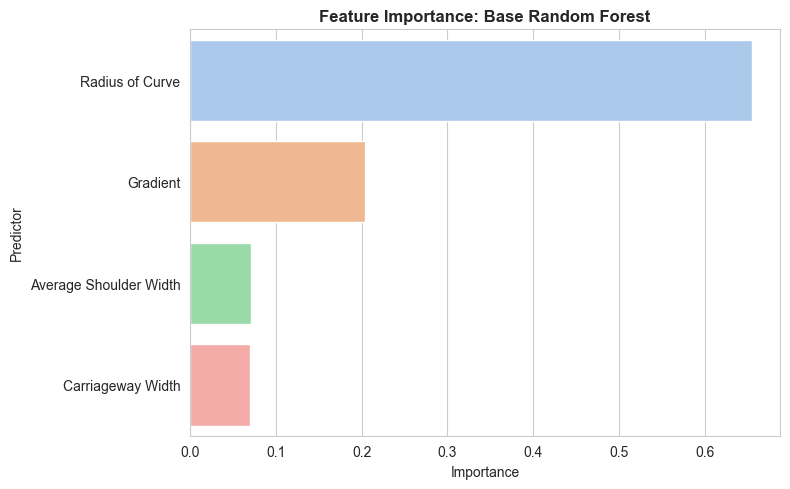

In [41]:
# ============================================================
# BASE RF FEATURE-IMPORTANCE PLOT
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rf_reduced_importance,
    x="Importance",
    y="Feature",
    palette="pastel"
)

plt.title(
    "Feature Importance: Base Random Forest",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# BASE RF ACTUAL AND PREDICTED VALUES
# ============================================================

rf_reduced_prediction_table = pd.DataFrame({
    "Actual V85": y_test_reduced,
    "Predicted V85": y_test_pred_rf_reduced
})

rf_reduced_prediction_table["Residual"] = (
    rf_reduced_prediction_table["Actual V85"] -
    rf_reduced_prediction_table["Predicted V85"]
)

rf_reduced_prediction_table["Absolute Error"] = (
    rf_reduced_prediction_table["Residual"].abs()
)

rf_reduced_prediction_table = (
    rf_reduced_prediction_table
    .sort_index()
)

display(
    rf_reduced_prediction_table.round(3)
)

,Actual V85,Predicted V85,Residual,Absolute Error
9,49.55,48.814,0.736,0.736
12,58.20,55.066,3.134,3.134
15,48.00,46.136,1.864,1.864
16,43.00,45.231,-2.231,2.231
18,45.00,40.668,4.332,4.332
19,42.00,42.045,-0.045,0.045
24,39.00,35.882,3.118,3.118
29,50.30,50.784,-0.484,0.484
30,44.00,42.285,1.715,1.715
31,33.00,34.437,-1.437,1.437


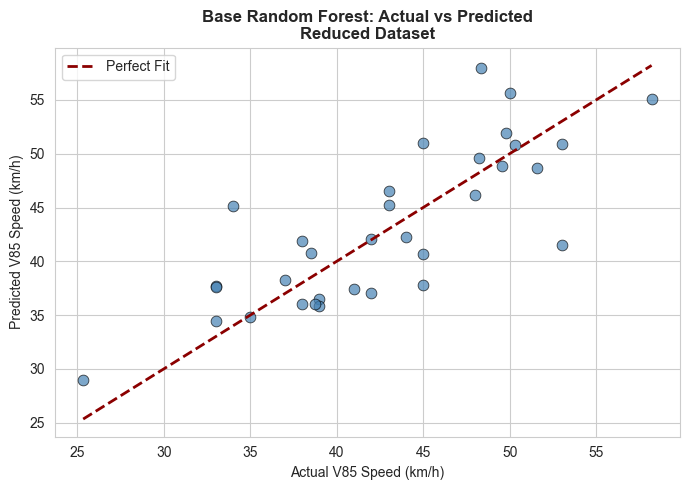

In [43]:
# ============================================================
# BASE RF: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_reduced,
    y=y_test_pred_rf_reduced,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

minimum_value = min(
    y_test_reduced.min(),
    y_test_pred_rf_reduced.min()
)

maximum_value = max(
    y_test_reduced.max(),
    y_test_pred_rf_reduced.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed (km/h)")
plt.ylabel("Predicted V85 Speed (km/h)")

plt.title(
    "Base Random Forest: Actual vs Predicted\n"
    "Reduced Dataset",
    fontsize=12,
    fontweight="bold"
)

plt.legend()
plt.tight_layout()
plt.show()

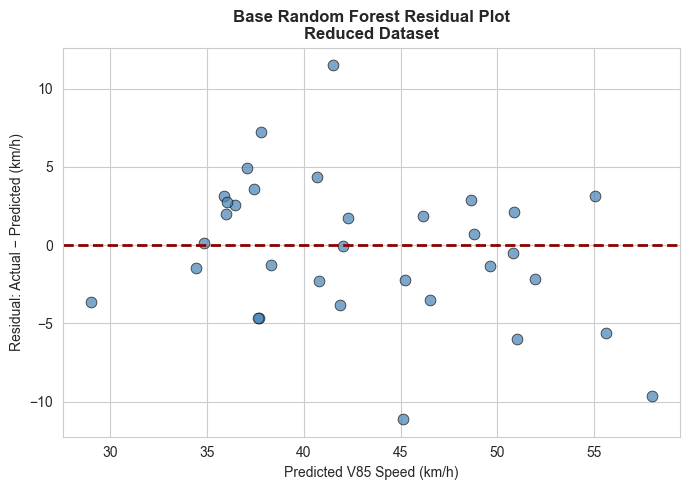

In [44]:
# ============================================================
# BASE RF: RESIDUAL PLOT
# ============================================================

rf_reduced_residuals = (
    y_test_reduced -
    y_test_pred_rf_reduced
)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_pred_rf_reduced,
    y=rf_reduced_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    color="darkred",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted V85 Speed (km/h)")
plt.ylabel("Residual: Actual − Predicted (km/h)")

plt.title(
    "Base Random Forest Residual Plot\n"
    "Reduced Dataset",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# STORE BASE RF RESULT
# ============================================================

rf_reduced_final = pd.DataFrame({
    "Model": [
        "Base Random Forest — Reduced Dataset"
    ],

    "Observations": [
        len(df_reduced)
    ],

    "R2": [
        rf_reduced_test_r2
    ],

    "RMSE": [
        rf_reduced_test_rmse
    ],

    "MAE": [
        rf_reduced_test_mae
    ]
})

display(
    rf_reduced_final.round(3)
)

,Model,Observations,R2,RMSE,MAE
0,Base Random Forest — Reduced Dataset,164,0.598,4.56,3.593


In [46]:
# ============================================================
# MLR VS BASE RANDOM FOREST
# ============================================================

initial_reduced_model_comparison = pd.concat(
    [
        mlr_reduced_final,
        rf_reduced_final
    ],
    ignore_index=True
)

display(
    initial_reduced_model_comparison.round(3)
)

,Model,Observations,R2,RMSE,MAE
0,MLR — Reduced Dataset,164,0.283,6.088,4.803
1,Base Random Forest — Reduced Dataset,164,0.598,4.560,3.593


In [47]:
# ============================================================
# CORRECTED RANDOM FOREST HYPERPARAMETER GRID
# ============================================================

param_grid_rf_reduced = {

    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        5,
        10,
        15
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        1.0,
        "sqrt",
        "log2"
    ]
}

print("Corrected parameter grid created.")

Corrected parameter grid created.


In [48]:
# ============================================================
# CROSS-VALIDATION SCORING
# ============================================================

rf_scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

print("Cross-validation scoring metrics defined.")

Cross-validation scoring metrics defined.


In [49]:
# ============================================================
# CONFIGURE RANDOM FOREST GRID SEARCH
# Best model selected using RMSE
# ============================================================

grid_rf_reduced = GridSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid_rf_reduced,

    scoring=rf_scoring,

    refit="RMSE",

    cv=5,

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

print("GridSearchCV configured successfully.")

GridSearchCV configured successfully.


In [50]:
# ============================================================
# RUN RANDOM FOREST HYPERPARAMETER TUNING
# UNSCALED TRAINING DATA
# ============================================================

grid_rf_reduced.fit(
    X_train_reduced,
    y_train_reduced
)

print("\nRandom Forest tuning completed successfully.")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Random Forest tuning completed successfully.


In [51]:
# ============================================================
# BEST RANDOM FOREST PARAMETERS
# ============================================================

print("=" * 60)
print("BEST RANDOM FOREST PARAMETERS")
print("=" * 60)

for parameter, value in grid_rf_reduced.best_params_.items():
    print(f"{parameter}: {value}")

BEST RANDOM FOREST PARAMETERS
max_depth: 10
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 5
n_estimators: 200


In [52]:
# ============================================================
# CROSS-VALIDATION PERFORMANCE OF BEST RF
# ============================================================

rf_cv_results = pd.DataFrame(
    grid_rf_reduced.cv_results_
)

best_index = grid_rf_reduced.best_index_

best_cv_r2 = (
    rf_cv_results.loc[
        best_index,
        "mean_test_R2"
    ]
)

best_cv_rmse = -(
    rf_cv_results.loc[
        best_index,
        "mean_test_RMSE"
    ]
)

best_cv_mae = -(
    rf_cv_results.loc[
        best_index,
        "mean_test_MAE"
    ]
)

best_cv_r2_sd = (
    rf_cv_results.loc[
        best_index,
        "std_test_R2"
    ]
)

best_cv_rmse_sd = (
    rf_cv_results.loc[
        best_index,
        "std_test_RMSE"
    ]
)

best_cv_mae_sd = (
    rf_cv_results.loc[
        best_index,
        "std_test_MAE"
    ]
)

rf_best_cv_performance = pd.DataFrame({
    "Metric": [
        "R2",
        "RMSE",
        "MAE"
    ],

    "CV Mean": [
        best_cv_r2,
        best_cv_rmse,
        best_cv_mae
    ],

    "CV Standard Deviation": [
        best_cv_r2_sd,
        best_cv_rmse_sd,
        best_cv_mae_sd
    ]
})

display(
    rf_best_cv_performance.round(3)
)

,Metric,CV Mean,CV Standard Deviation
0,R2,0.510,0.124
1,RMSE,6.706,1.121
2,MAE,5.294,1.012


In [53]:
# ============================================================
# TOP 10 RANDOM FOREST PARAMETER COMBINATIONS
# ============================================================

rf_cv_summary = pd.DataFrame({

    "Rank": (
        rf_cv_results[
            "rank_test_RMSE"
        ]
    ),

    "CV R2": (
        rf_cv_results[
            "mean_test_R2"
        ]
    ),

    "CV RMSE": -(
        rf_cv_results[
            "mean_test_RMSE"
        ]
    ),

    "CV MAE": -(
        rf_cv_results[
            "mean_test_MAE"
        ]
    ),

    "n_estimators": (
        rf_cv_results[
            "param_n_estimators"
        ]
    ),

    "max_depth": (
        rf_cv_results[
            "param_max_depth"
        ]
    ),

    "min_samples_split": (
        rf_cv_results[
            "param_min_samples_split"
        ]
    ),

    "min_samples_leaf": (
        rf_cv_results[
            "param_min_samples_leaf"
        ]
    ),

    "max_features": (
        rf_cv_results[
            "param_max_features"
        ]
    )
})

rf_cv_summary = (
    rf_cv_summary
    .sort_values("Rank")
    .reset_index(drop=True)
)

display(
    rf_cv_summary.head(10).round(3)
)

,Rank,CV R2,CV RMSE,CV MAE,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,1,0.510,6.706,5.294,200,10,5,1,log2
1,1,0.510,6.706,5.294,200,10,5,1,sqrt
2,3,0.510,6.707,5.296,200,None,5,1,sqrt
3,3,0.510,6.707,5.296,200,15,5,1,log2
4,3,0.510,6.707,5.296,200,15,5,1,sqrt
5,3,0.510,6.707,5.296,200,None,5,1,log2
6,7,0.506,6.727,5.258,300,5,10,2,1.0
7,8,0.506,6.730,5.341,100,None,5,1,log2
8,8,0.506,6.730,5.341,100,None,5,1,sqrt
9,8,0.506,6.730,5.341,100,15,5,1,sqrt


In [54]:
# ============================================================
# EXTRACT BEST TUNED RANDOM FOREST
# ============================================================

best_rf_reduced = (
    grid_rf_reduced.best_estimator_
)

print("Best tuned Random Forest:\n")
print(best_rf_reduced)

Best tuned Random Forest:

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_split=5,
                      n_estimators=200, random_state=42)


In [55]:
# ============================================================
# TUNED RANDOM FOREST PREDICTIONS
# ============================================================

y_train_pred_rf_reduced_tuned = (
    best_rf_reduced.predict(
        X_train_reduced
    )
)

y_test_pred_rf_reduced_tuned = (
    best_rf_reduced.predict(
        X_test_reduced
    )
)

print(
    "Training predictions:",
    len(y_train_pred_rf_reduced_tuned)
)

print(
    "Testing predictions:",
    len(y_test_pred_rf_reduced_tuned)
)

Training predictions: 131
Testing predictions: 33


In [56]:
# ============================================================
# TUNED RF TRAINING METRICS
# ============================================================

rf_tuned_train_r2 = r2_score(
    y_train_reduced,
    y_train_pred_rf_reduced_tuned
)

rf_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train_reduced,
        y_train_pred_rf_reduced_tuned
    )
)

rf_tuned_train_mae = mean_absolute_error(
    y_train_reduced,
    y_train_pred_rf_reduced_tuned
)

In [57]:
# ============================================================
# TUNED RF TEST METRICS
# ============================================================

rf_tuned_test_r2 = r2_score(
    y_test_reduced,
    y_test_pred_rf_reduced_tuned
)

rf_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test_reduced,
        y_test_pred_rf_reduced_tuned
    )
)

rf_tuned_test_mae = mean_absolute_error(
    y_test_reduced,
    y_test_pred_rf_reduced_tuned
)

In [58]:
# ============================================================
# TRAINING VS TESTING PERFORMANCE
# ============================================================

rf_tuned_train_test_results = pd.DataFrame({

    "Dataset": [
        "Training",
        "Testing"
    ],

    "R2": [
        rf_tuned_train_r2,
        rf_tuned_test_r2
    ],

    "RMSE": [
        rf_tuned_train_rmse,
        rf_tuned_test_rmse
    ],

    "MAE": [
        rf_tuned_train_mae,
        rf_tuned_test_mae
    ]
})

display(
    rf_tuned_train_test_results.round(3)
)

,Dataset,R2,RMSE,MAE
0,Training,0.859,3.691,2.878
1,Testing,0.589,4.611,3.503


In [59]:
# ============================================================
# CV VS INDEPENDENT TEST PERFORMANCE
# ============================================================

rf_cv_vs_test = pd.DataFrame({

    "Evaluation": [
        "5-Fold Cross-Validation",
        "Independent Test Set"
    ],

    "R2": [
        best_cv_r2,
        rf_tuned_test_r2
    ],

    "RMSE": [
        best_cv_rmse,
        rf_tuned_test_rmse
    ],

    "MAE": [
        best_cv_mae,
        rf_tuned_test_mae
    ]
})

display(
    rf_cv_vs_test.round(3)
)

,Evaluation,R2,RMSE,MAE
0,5-Fold Cross-Validation,0.510,6.706,5.294
1,Independent Test Set,0.589,4.611,3.503


In [60]:
# ============================================================
# TUNED RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_tuned_importance = pd.DataFrame({

    "Feature": X_train_reduced.columns,

    "Importance": (
        best_rf_reduced.feature_importances_
    )
})

rf_tuned_importance = (
    rf_tuned_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_tuned_importance.round(4)
)

,Feature,Importance
0,Radius of Curve,0.6224
1,Gradient,0.2115
2,Average Shoulder Width,0.0899
3,Carriageway Width,0.0762


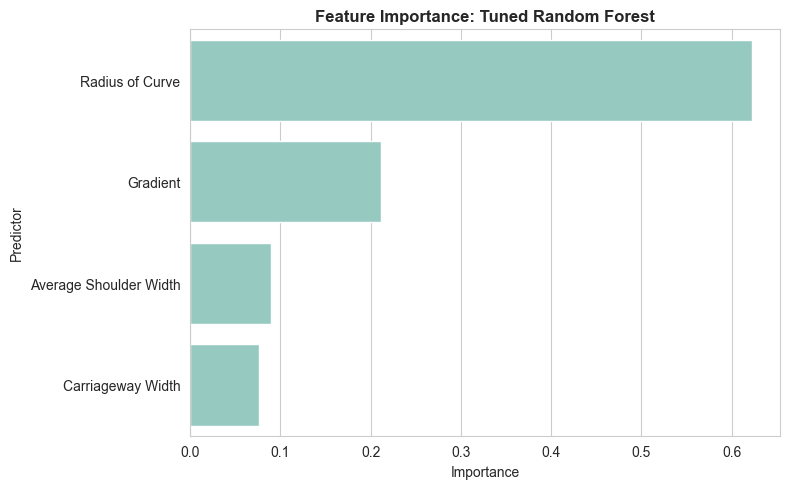

In [61]:
# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rf_tuned_importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance: Tuned Random Forest",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

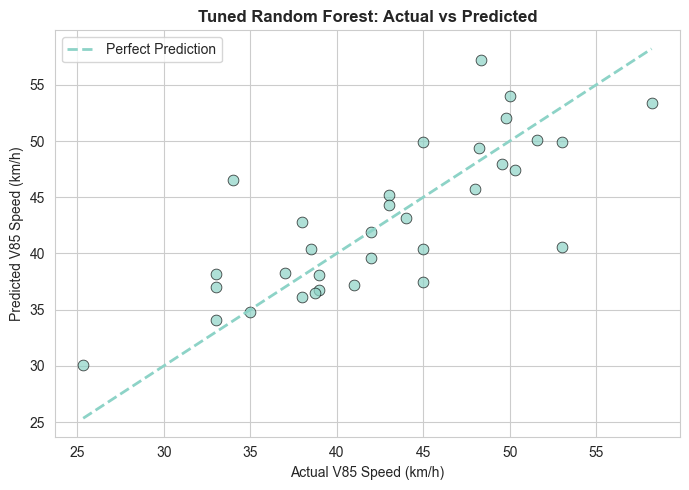

In [62]:
# ============================================================
# TUNED RF: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_reduced,
    y=y_test_pred_rf_reduced_tuned,
    s=60,
    alpha=0.7,
    edgecolor="black"
)

minimum_value = min(
    y_test_reduced.min(),
    y_test_pred_rf_reduced_tuned.min()
)

maximum_value = max(
    y_test_reduced.max(),
    y_test_pred_rf_reduced_tuned.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel(
    "Actual V85 Speed (km/h)"
)

plt.ylabel(
    "Predicted V85 Speed (km/h)"
)

plt.title(
    "Tuned Random Forest: Actual vs Predicted",
    fontsize=12,
    fontweight="bold"
)

plt.legend()
plt.tight_layout()
plt.show()

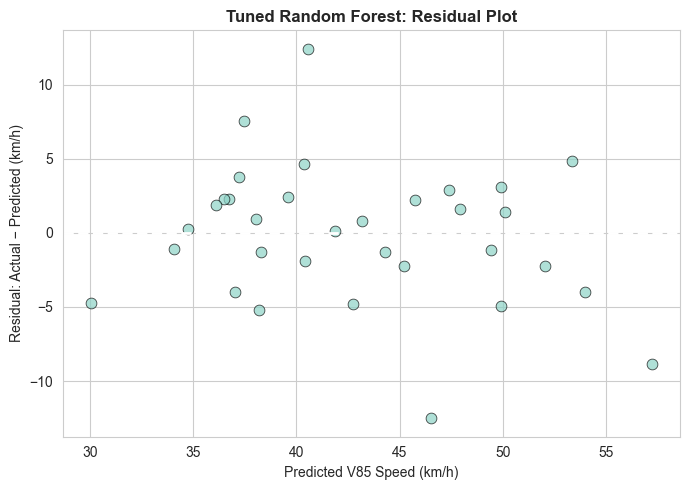

In [63]:
# ============================================================
# TUNED RF: RESIDUAL PLOT
# ============================================================

rf_tuned_residuals = (
    y_test_reduced -
    y_test_pred_rf_reduced_tuned
)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_pred_rf_reduced_tuned,
    y=rf_tuned_residuals,
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Predicted V85 Speed (km/h)"
)

plt.ylabel(
    "Residual: Actual − Predicted (km/h)"
)

plt.title(
    "Tuned Random Forest: Residual Plot",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [64]:
# ============================================================
# STORE TUNED RANDOM FOREST RESULTS
# ============================================================

rf_reduced_tuned_final = pd.DataFrame({

    "Model": [
        "Tuned Random Forest — Reduced Dataset"
    ],

    "Observations": [
        len(df_reduced)
    ],

    "R2": [
        rf_tuned_test_r2
    ],

    "RMSE": [
        rf_tuned_test_rmse
    ],

    "MAE": [
        rf_tuned_test_mae
    ]
})

display(
    rf_reduced_tuned_final.round(3)
)

,Model,Observations,R2,RMSE,MAE
0,Tuned Random Forest — Reduced Dataset,164,0.589,4.611,3.503


In [65]:
# ============================================================
# BASE RANDOM FOREST VS CORRECTED TUNED RANDOM FOREST
# ============================================================

rf_final_comparison = pd.concat(
    [
        rf_reduced_final,
        rf_reduced_tuned_final
    ],
    ignore_index=True
)

display(
    rf_final_comparison.round(3)
)

,Model,Observations,R2,RMSE,MAE
0,Base Random Forest — Reduced Dataset,164,0.598,4.560,3.593
1,Tuned Random Forest — Reduced Dataset,164,0.589,4.611,3.503


In [66]:
# ============================================================
# CHECK BASE RF AND TUNED RF PARAMETERS
# ============================================================

print("BASE RANDOM FOREST PARAMETERS")
print("-" * 50)

base_parameters = {
    "n_estimators": rf_reduced.n_estimators,
    "max_depth": rf_reduced.max_depth,
    "min_samples_split": rf_reduced.min_samples_split,
    "min_samples_leaf": rf_reduced.min_samples_leaf,
    "max_features": rf_reduced.max_features
}

for parameter, value in base_parameters.items():
    print(f"{parameter}: {value}")


print("\nTUNED RANDOM FOREST PARAMETERS")
print("-" * 50)

for parameter, value in grid_rf_reduced.best_params_.items():
    print(f"{parameter}: {value}")

BASE RANDOM FOREST PARAMETERS
--------------------------------------------------
n_estimators: 100
max_depth: None
min_samples_split: 2
min_samples_leaf: 1
max_features: 1.0

TUNED RANDOM FOREST PARAMETERS
--------------------------------------------------
max_depth: 10
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 5
n_estimators: 200


In [67]:
# ============================================================
# COMPARE BASE RF AND TUNED RF USING THE SAME 5-FOLD CV
# ============================================================

from sklearn.model_selection import cross_validate

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

# ------------------------------------------------------------
# BASE RF
# ------------------------------------------------------------

base_rf_cv = cross_validate(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    X=X_train_reduced,
    y=y_train_reduced,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

# ------------------------------------------------------------
# TUNED RF
# ------------------------------------------------------------

tuned_rf_cv = cross_validate(
    estimator=best_rf_reduced,
    X=X_train_reduced,
    y=y_train_reduced,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

cv_comparison = pd.DataFrame({

    "Model": [
        "Base Random Forest",
        "Tuned Random Forest"
    ],

    "Mean CV R2": [
        base_rf_cv["test_R2"].mean(),
        tuned_rf_cv["test_R2"].mean()
    ],

    "Mean CV RMSE": [
        -base_rf_cv["test_RMSE"].mean(),
        -tuned_rf_cv["test_RMSE"].mean()
    ],

    "Mean CV MAE": [
        -base_rf_cv["test_MAE"].mean(),
        -tuned_rf_cv["test_MAE"].mean()
    ],

    "SD CV R2": [
        base_rf_cv["test_R2"].std(),
        tuned_rf_cv["test_R2"].std()
    ],

    "SD CV RMSE": [
        (-base_rf_cv["test_RMSE"]).std(),
        (-tuned_rf_cv["test_RMSE"]).std()
    ]
})

display(
    cv_comparison.round(3)
)

,Model,Mean CV R2,Mean CV RMSE,Mean CV MAE,SD CV R2,SD CV RMSE
0,Base Random Forest,0.463,6.965,5.558,0.147,1.019
1,Tuned Random Forest,0.510,6.706,5.294,0.124,1.121
